In [36]:
import duckdb
import pandas as pd


con = duckdb.connect('../capillary.db')
df = con.execute("""
                SELECT id,
                    any_value(s_kappa) as s_kappa,
                    any_value(s_lambda) as s_lambda,
                    any_value(s_kl_kvot) as s_kl_kvot,
                    list(c.comment_nr) as comment_nr,
                FROM protein_data p
                LEFT JOIN comment_precences c 
                    ON p.id = c.row_id
                GROUP BY id
                 """).df()

con.close()
comment_range= [203,204]
df_203 = df[df['comment_nr'].apply(lambda x: 203 in x)]
df_204 = df[df['comment_nr'].apply(lambda x: 204 in x)]
df_207 = df[df['comment_nr'].apply(lambda x: 207 in x)]
df_208 = df[df['comment_nr'].apply(lambda x: 208 in x)]
print(len(df_203))
print(len(df_204))
print((len(df_204)/len(df_203)))
print((len(df_207)/len(df_208)))

5984
2680
0.44786096256684493
1.5248838752488387


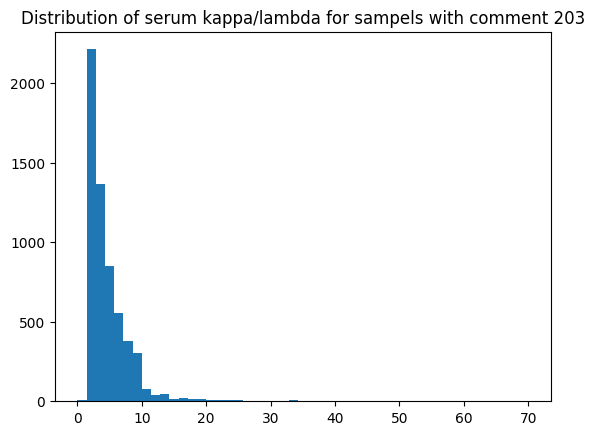

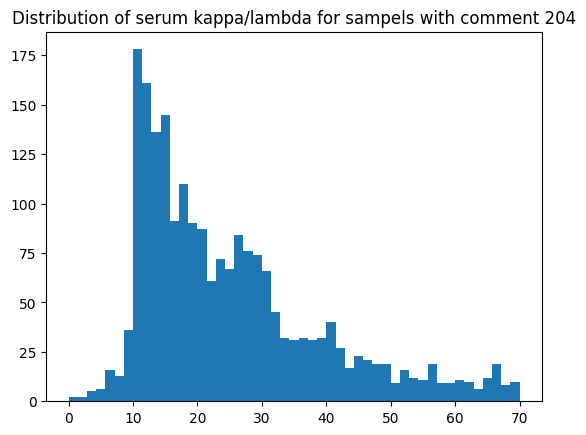

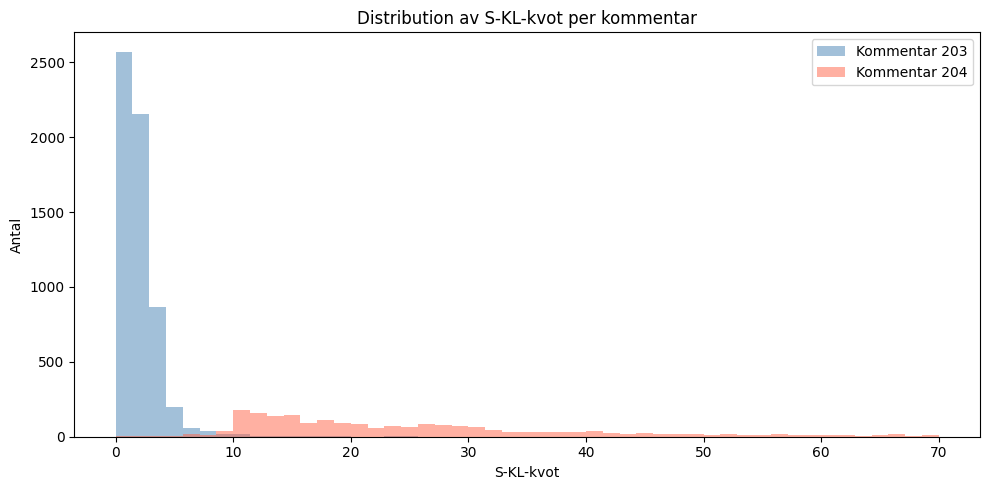

In [29]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure()
my_bins = np.linspace(0,70,50)

plt.hist(df_203['s_kl_kvot'],bins=my_bins)
plt.title("Distribution of serum kappa/lambda for sampels with comment 203")
plt.show()

plt.figure()
plt.hist(df_204['s_kl_kvot'],bins=my_bins)
plt.title("Distribution of serum kappa/lambda for sampels with comment 204")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_203['s_kl_kvot'].dropna()*(len(df_204)/len(df_203)), bins=my_bins, alpha=0.5, color='steelblue', label='Kommentar 203')
ax.hist(df_204['s_kl_kvot'].dropna(), bins=my_bins, alpha=0.5, color='tomato', label='Kommentar 204')

ax.set_xlabel("S-KL-kvot")
ax.set_ylabel("Antal")
ax.set_title("Distribution av S-KL-kvot per kommentar")
ax.legend()
plt.tight_layout()
plt.show()

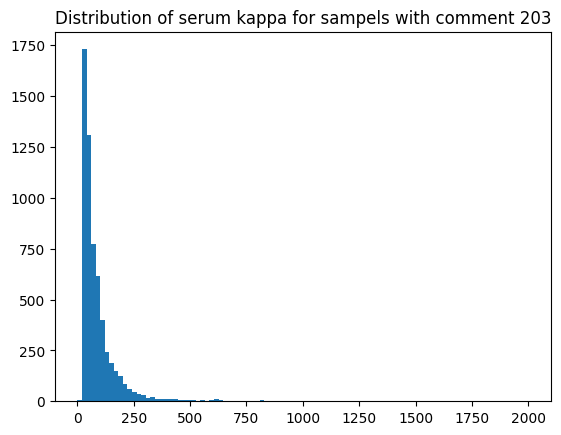

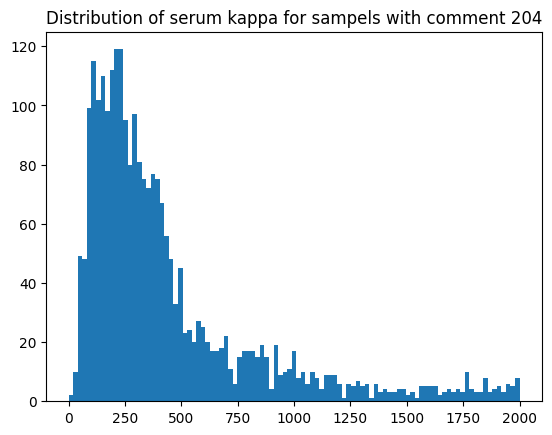

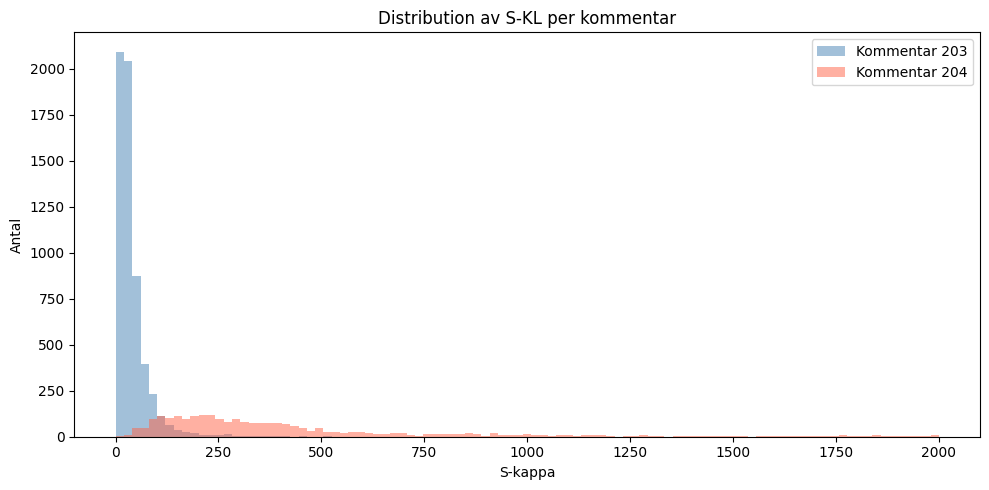

In [32]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure()
my_bins = np.linspace(0,2000,100)

plt.hist(df_203['s_kappa'],bins=my_bins)
plt.title("Distribution of serum kappa for sampels with comment 203")
plt.show()

plt.figure()
plt.hist(df_204['s_kappa'],bins=my_bins)
plt.title("Distribution of serum kappa for sampels with comment 204")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_203['s_kappa'].dropna()*(len(df_204)/len(df_203)), bins=my_bins, alpha=0.5, color='steelblue', label='Kommentar 203')
ax.hist(df_204['s_kappa'].dropna(), bins=my_bins, alpha=0.5, color='tomato', label='Kommentar 204')

ax.set_xlabel("S-kappa")
ax.set_ylabel("Antal")
ax.set_title("Distribution av S-KL per kommentar")
ax.legend()
plt.tight_layout()
plt.show()

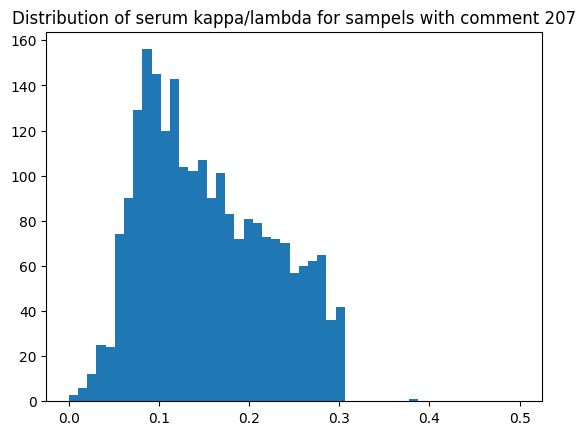

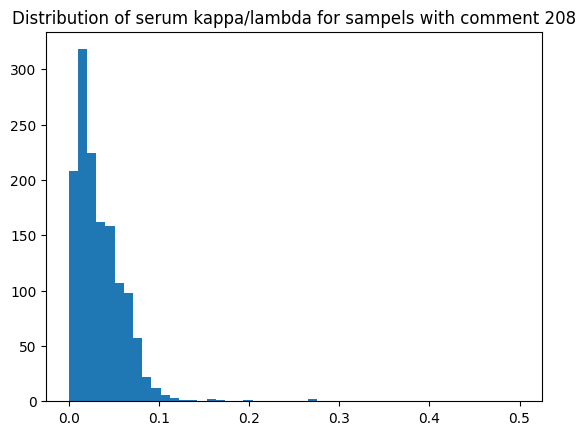

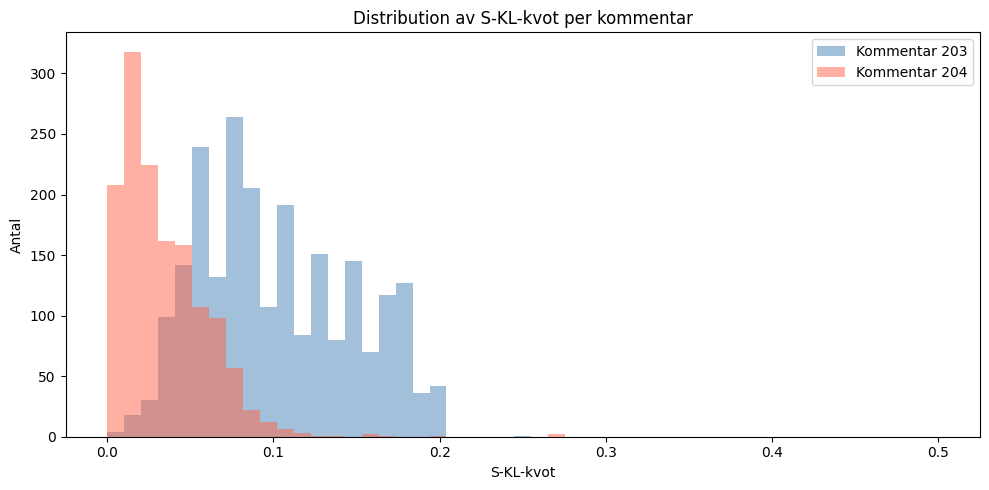

In [37]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure()
my_bins = np.linspace(0,0.5,50)

plt.hist(df_207['s_kl_kvot'],bins=my_bins)
plt.title("Distribution of serum kappa/lambda for sampels with comment 207")
plt.show()

plt.figure()
plt.hist(df_208['s_kl_kvot'],bins=my_bins)
plt.title("Distribution of serum kappa/lambda for sampels with comment 208")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_207['s_kl_kvot'].dropna()*(len(df_208)/len(df_207)), bins=my_bins, alpha=0.5, color='steelblue', label='Kommentar 203')
ax.hist(df_208['s_kl_kvot'].dropna(), bins=my_bins, alpha=0.5, color='tomato', label='Kommentar 204')

ax.set_xlabel("S-KL-kvot")
ax.set_ylabel("Antal")
ax.set_title("Distribution av S-KL-kvot per kommentar")
ax.legend()
plt.tight_layout()
plt.show()

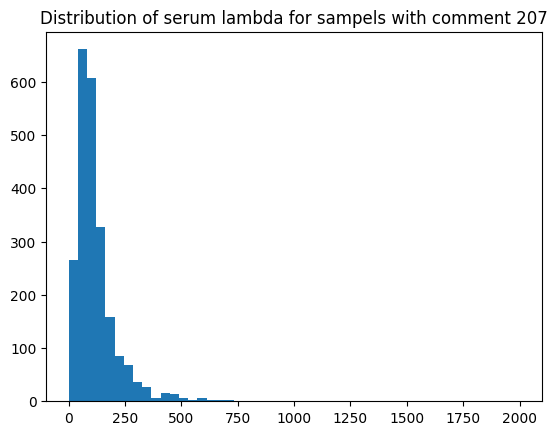

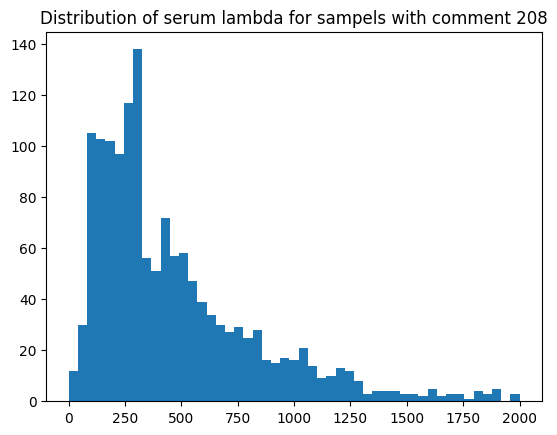

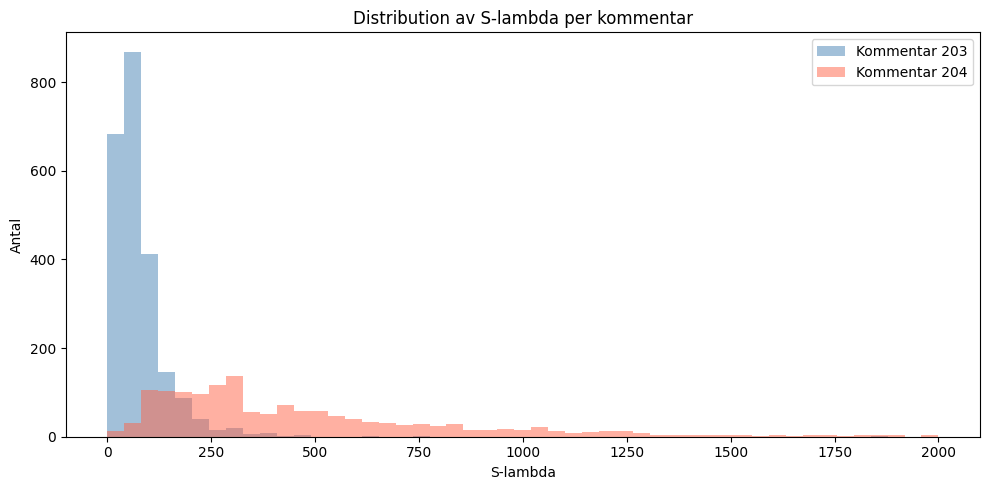

In [38]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure()
my_bins = np.linspace(0,2000,50)

plt.hist(df_207['s_lambda'],bins=my_bins)
plt.title("Distribution of serum lambda for sampels with comment 207")
plt.show()

plt.figure()
plt.hist(df_208['s_lambda'],bins=my_bins)
plt.title("Distribution of serum lambda for sampels with comment 208")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_207['s_lambda'].dropna()*(len(df_208)/len(df_207)), bins=my_bins, alpha=0.5, color='steelblue', label='Kommentar 203')
ax.hist(df_208['s_lambda'].dropna(), bins=my_bins, alpha=0.5, color='tomato', label='Kommentar 204')

ax.set_xlabel("S-lambda")
ax.set_ylabel("Antal")
ax.set_title("Distribution av S-lambda per kommentar")
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
from functions.analyte import ANALYTES
from networks.cnn_dilated_convolutions import CNNModel
from networks.auto_encoder import AutoencoderModel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import duckdb
from sklearn.metrics import classification_report, confusion_matrix
from functions.full_model import predict



con = duckdb.connect('../capillary.db')

df = con.execute(""" 
                 SELECT id, age, gender, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm,s_kappa,s_lambda,s_kl_kvot,u_albumin_krea,u_igg_krea,u_kappa_krea,u_lambda_krea,u_hc_krea,u_kappa,u_lambda,u_kreatinin, label, set, interpretation
                 FROM protein_data 
                 WHERE value IS NOT NULL
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 AND observation_nr = 1
                 """).df()

con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]

protein_cols = [a.col for a in ANALYTES[:11]]  # bara de 8 första
df = df.dropna(subset=protein_cols)
y = df['label']

cnn = CNNModel()
ae = AutoencoderModel()
df = cnn.predict(df)


def build_x(df):
    positive_deviation = np.maximum(0,df['s_kl_kvot'] - 1.56)
    negative_deviation = np.maximum(0,0.31 - df['s_kl_kvot'] )
    diff = np.abs( df['s_kappa'] - df['s_lambda'])
    prob = df['cnn_probability']
    return np.column_stack([positive_deviation, negative_deviation, diff, prob])

df = df[(df['label'] == 0) | (df['label'] == 1)]
train = df[df['set'] == 'train']
val  = df[df['set'] == 'val']

In [23]:
import joblib
X_train = build_x(train)
y_train = np.array(train['label'])
print("Med modellen")
model = LogisticRegression(class_weight='balanced').fit(X_train, y_train)

X_test = build_x(val)
y_test = np.array(val['label'])

predictions = model.predict(X_test)
prev_predictions = (val['cnn_probability'] > 0.2).astype(int)
print(classification_report(y_test, predictions, target_names=['Negativ', 'Positiv']))

print(confusion_matrix(y_test, predictions))

probs = model.predict_proba(X_test)[:, 1]
print(model.coef_)

print("\n---------------\nUtan modellen\n---------------")
print(classification_report(y_test, prev_predictions, target_names=['Negativ', 'Positiv']))
print(confusion_matrix(y_test, prev_predictions))
joblib.dump(model,'../models/free_light_chains.pkl')


Med modellen
              precision    recall  f1-score   support

     Negativ       0.99      0.92      0.95       110
     Positiv       0.82      0.98      0.89        42

    accuracy                           0.93       152
   macro avg       0.91      0.95      0.92       152
weighted avg       0.94      0.93      0.94       152

[[101   9]
 [  1  41]]
[[-3.71261349e-03  3.43992267e-01 -7.50425572e-05  8.37616796e+00]]

---------------
Utan modellen
---------------
              precision    recall  f1-score   support

     Negativ       1.00      0.87      0.93       110
     Positiv       0.75      1.00      0.86        42

    accuracy                           0.91       152
   macro avg       0.88      0.94      0.89       152
weighted avg       0.93      0.91      0.91       152

[[96 14]
 [ 0 42]]


['../models/free_light_chains.pkl']